# Access LSST alert cutouts served by $\texttt{Pitt-Google}$ via Google Cloud Storage

The $\texttt{Pitt-Google Alert Broker's}$ LSST Avro alert data (including cutouts) are stored in Google Cloud Storage (GCS). The GCS bucket names and alert Avro filename syntax are outlined in our [data listings page](https://mwvgroup.github.io/pittgoogle-client/listings.html#cloud-storage-buckets).

## Table of Contents

- [Extract a LSST alert from $\texttt{Pitt-Google}$'s GCS bucket](#extract-a-lsst-alert-from-pitt-googles-gcs-bucket)
- [Inspect cutout data from a LSST alert](#inspect-cutout-data-from-a-lsst-alert)
- [Plot cutouts from a LSST alert](#plot-cutouts-from-a-lsst-alert)

## Prerequisites

- Complete the [One-Time Setup](https://mwvgroup.github.io/pittgoogle-client/one-time-setup/index.html#one-time-setup), specifically:
     - Install the pittgoogle-client package
     - Setup authentication to a Google Cloud project
     - Set environment variables
     - Enable the Google Cloud Storage API
     - You can skip the command-line tools

In [1]:
import io
import matplotlib.pyplot as plt
import pittgoogle
from astropy.io import fits
from google.cloud import storage
from google.cloud.pubsub_v1.types import PubsubMessage

# load authentication credentials
user_auth = pittgoogle.auth.Auth(
    GOOGLE_CLOUD_PROJECT="name-of-your-gcp-project", # UPDATE ME
    GOOGLE_APPLICATION_CREDENTIALS="path-to-service-account-key", # UPDATE ME
)

<a id="extract-a-lsst-alert-from-pitt-googles-gcs-bucket"></a>
## Extract a LSST alert from $\texttt{Pitt-Google}$'s GCS bucket

LSST alert Avro files are *objects* stored in a GCS bucket. Extracting an alert from the bucket requires defining a filepath, or list of filepaths, to the Avro file(s).


$\texttt{Pitt-Google}$ uses the following syntax to store Avro file archives of the LSST alert stream:
- `v<alert_schema_version>/kafkaPublishTimestamp=<kafka_timestamp>/<objectid_key>=<objectid>/<sourceid_key>=<sourceid>.avro`

The possible `<objectid_key>` values are `diaObjectId` or `ssObjectId`.

Examples are outlined below:
- `v10_0/kafkaPublishTimestamp=2026-02-25/diaObjectId=170028526486945858/diaSourceId=170055002405994505.avro`
- `v11_0_kafkaPublishTimestamp=2026-05-22/ssObjectId=21164723874183510/diaSourceId=170433141484815220.avro`
- `v11_1/kafkaPublishTimestamp=2026-07-14/diaObjectId=170019696269590551/diaSourceId=170666304476282912.avro`

Run the cells below to extract a LSST alert (`diaObjectId = 170028526486945858`, `diaSourceId = 170055002405994505`) from $\texttt{Pitt-Google}$'s GCS bucket and inspect its content.

In [2]:
def extract_lsst_alert(alert_path, credentials):
    """Downloads an alert's Avro file from GCS and parses it into a pittgoogle Alert object.

    Args:
        alert_path (str): Path (blob name) of the alert's Avro file within the survey's GCS bucket.
        credentials (google.auth.credentials.Credentials): Credentials used to authenticate with GCS.

    Returns:
        pittgoogle.alert.Alert: The parsed alert object, constructed from the downloaded Avro bytes.
    """

    survey = "lsst"
    bucket_obj = get_gcs_bucket(credentials, project_id="pitt-alert-broker", survey=f"{survey}")

    # download the alert bytes from the GCS bucket
    blob = bucket_obj.blob(alert_path)
    avro_bytes = blob.download_as_bytes()

    # create Alert object
    blob.reload() # extract relevant metadata and add it to the Alert attributes
    pubsub_message = PubsubMessage(data=avro_bytes, attributes=blob.metadata)
    alert = pittgoogle.alert.Alert.from_msg(pubsub_message, schema_name=f"{survey}")

    return alert


def get_gcs_bucket(credentials, project_id, survey):
    """Gets a reference to a survey's alert-storage bucket in Google Cloud Storage.

    Args:
        credentials (google.auth.credentials.Credentials): Credentials used to authenticate with GCS.
        project_id (str): ID of the GCP project that owns the bucket.
        survey (str): Name of the survey, used to construct the bucket name (as "{project_id}-{survey}_alerts").

    Returns:
        google.cloud.storage.bucket.Bucket: The bucket containing the survey's alerts.
    """

    bucket_name = f"{project_id}-{survey}_alerts"
    client = storage.Client(project=project_id, credentials=credentials)

    return client.bucket(bucket_name, user_project=project_id)

In [3]:
# define variables to extract a single alert object from GCS
VERSIONTAG = "v10_0"
DATE = "2026-02-25" # YYYY-MM-DD format required
DIAOBJECTID = "170028526486945858"
DIASOURCEID = "170055002405994505"
alert_path = f"{VERSIONTAG}/kafkaPublishTimestamp={DATE}/diaObjectId={DIAOBJECTID}/diaSourceId={DIASOURCEID}.avro"

# extract alert
alert = extract_lsst_alert(alert_path=alert_path, credentials=user_auth.credentials)

# uncomment the line below to inspect the Alert content
# alert.dict

<a id="inspect-cutout-data-from-a-lsst-alert"></a>
## Inspect cutout data from a LSST alert

Every LSST alert contains the fields: `cutoutScience`, `cutoutTemplate`, and `cutoutDifference`. 

The variable-size cutouts will be sized so as to encompass the entire footprint of the detected source, but be no smaller than `30x30` pixels. The provided images will comprise of a flux (32 bit float), variance (32 bit float), and mask (at least 16 bit flags) planes, and include metadata necessary for further processing (e.g., WCS, zero-point, PSF, etc.). (source: [Data Products Definition Document](https://lse-163.lsst.io))

Run the cells below to decode and inspect the data of an alert cutout.

In [4]:
def decode_cutout(cutout_bytes):
    """Decode the FITS data from a byte string and return a numpy array."""
    with fits.open(io.BytesIO(cutout_bytes)) as hdul:
        return hdul[0].data

In [5]:
cutout_science_data = decode_cutout(alert.dict["cutoutScience"])

# uncomment the line below to inspect the cutout content
# cutout_science_data

<a id="plot-cutouts-from-a-lsst-alert"></a>
## Plot cutouts from a LSST alert

Use the cells below to plot the individual cutouts of a LSST alert packet.

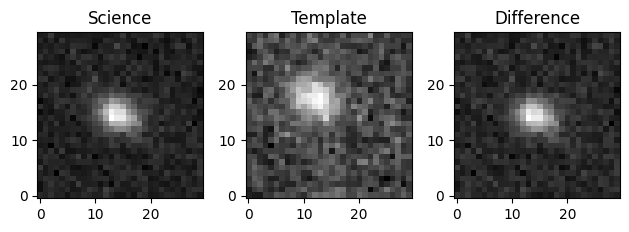

In [6]:
def plot_lsst_alert_cutouts(alert):
    """Plots the science, template, and difference cutouts for an LSST alert.

    Decodes and displays each cutout image side by side in a single figure.

    Args:
        alert_dict (dict): Alert data containing the cutout image bytes, keyed as "cutoutScience", "cutoutTemplate",
        and "cutoutDifference".

    Returns:
        None. Displays the figure via ``plt.show()``.
    """

    alert_dict = alert.dict
    cutouts = ["Science", "Template", "Difference"]
    fig, axes = plt.subplots(1, 3)

    for i, cutout in enumerate(cutouts):
        key = f"cutout{cutout}"
        cutout_bytes = alert_dict[key]
        # decode and plot the cutouts
        cutout_data = decode_cutout(cutout_bytes)
        axes[i].imshow(cutout_data, origin="lower", cmap="gray")
        axes[i].set_title(cutout)

    plt.tight_layout()
    plt.show()

# plot cutouts
plot_lsst_alert_cutouts(alert)